<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2021/lab_ch21_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [25]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = '82078b7e0f65bcf75cbf64afe01471d7'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error
2. A **seasonality omission** error
3. A **missing diagnostic** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

ADF test on log CPI:
  Test statistic: -1.3097
  P-value: 0.8855
  Conclusion: NON-STATIONARY

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0936      0.101     -0.931      0.352      -0.291       0.103
ar.L2          0.3738      0.065      5.787      0.000       0.247       0.500
ma.L1          0.8300      0.060     13.741      0.000       0.712       0.948
sigma2      1.156e-05   8.29e-07     13.936      0.000    9.93e-06    1.32e-05

AIC: -2661.19
BIC: -2646.21


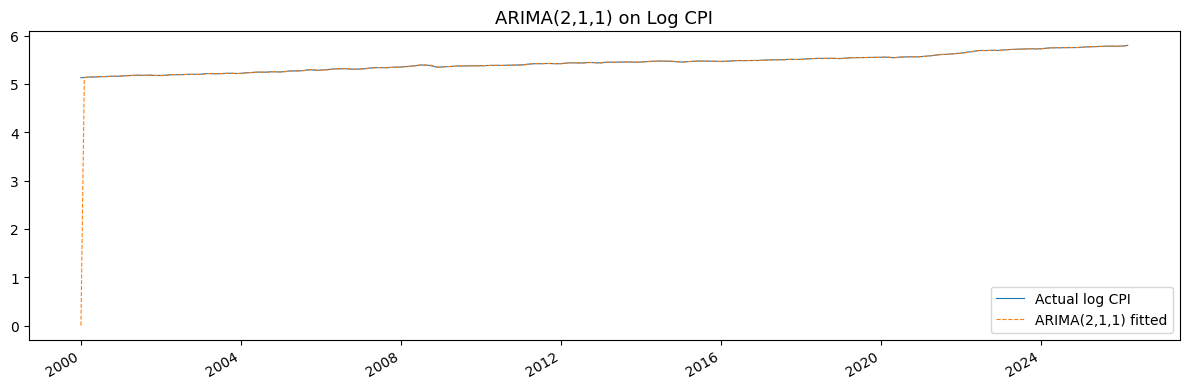

In [26]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Fit ARIMA to CPI
# -----------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
cpi.index = pd.to_datetime(cpi.index).to_period('M').to_timestamp()
cpi.name = 'CPI'
cpi_log = np.log(cpi)


# Check stationarity
adf_stat, adf_p, _, _, _, _ = adfuller(cpi_log, autolag='AIC', regression='ct')
print(f'ADF test on log CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()

# WRONG: ARIMA(2, 0, 1) on non-stationary data
# model = ARIMA(cpi_log, order=(2, 0, 1))

# CORRECT: difference once to achieve stationarity
model = ARIMA(cpi_log, order=(2, 1, 1))
result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# Plot fitted vs actual
fig, ax = plt.subplots(figsize=(12, 4))
cpi_log.plot(ax=ax, label='Actual log CPI', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,1,1) fitted',
                         linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,1,1) on Log CPI', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

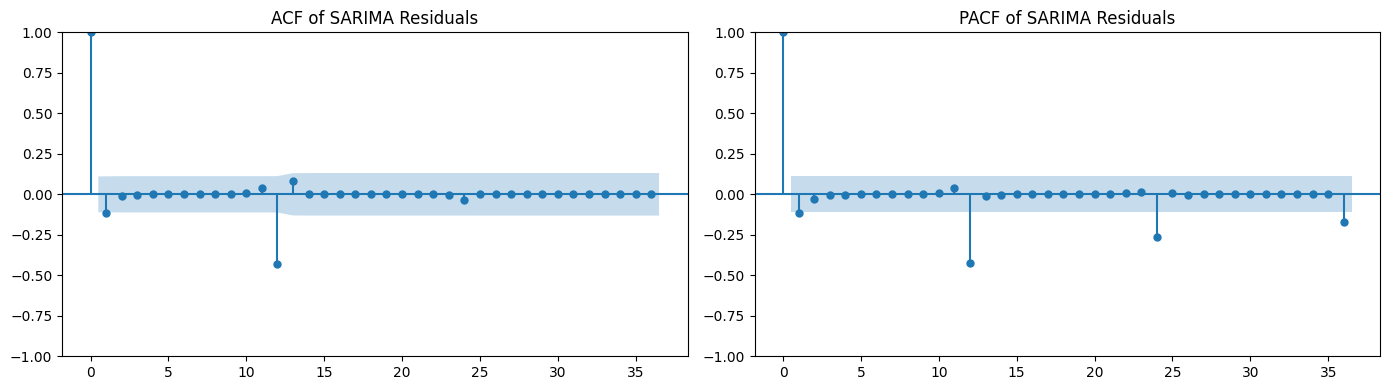

Look at lags 12, 24, 36 in the ACF plot.
Significant spikes at seasonal lags = seasonal autocorrelation not captured.

ACF at lag 12: -0.8005
ACF at lag 24: -0.8247
If these are large (> 0.1), seasonality is leaking into residuals.


In [27]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Refit with differencing but ignore seasonality
# -----------------------------------------------------------

# Suppose we fix d=1. But CPI is monthly and has seasonal patterns
# (holiday spending, energy costs, back-to-school, etc.).
# ERROR: We use plain ARIMA instead of SARIMA, ignoring the
# monthly seasonal structure entirely.
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    cpi_log,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=False)
residuals = fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of SARIMA Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of SARIMA Residuals')
plt.tight_layout()
plt.show()

print('Look at lags 12, 24, 36 in the ACF plot.')
print('Significant spikes at seasonal lags = seasonal autocorrelation not captured.')
print(f'\nACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('If these are large (> 0.1), seasonality is leaking into residuals.')

In [28]:
# -----------------------------------------------------------
# DIAGNOSE: Something critical is missing.
# Step 3: Skip residual diagnostics and go straight to forecasting
# -----------------------------------------------------------

# ERROR: We never run the Ljung-Box test on residuals.
# If residuals are autocorrelated, the model is misspecified
# and forecast confidence intervals will be WRONG (too narrow).
# A responsible pipeline ALWAYS checks Ljung-Box before forecasting.

# Jumping straight to forecast without diagnostic checks!
from statsmodels.stats.diagnostic import acorr_ljungbox

fit = model.fit(disp=False)
residuals = fit.resid

# Run Ljung-Box on residuals
lb_results = acorr_ljungbox(residuals, lags=[6, 12, 18, 24], return_df=True)
print(lb_results)

# Also check squared residuals for volatility clustering
lb_squared = acorr_ljungbox(residuals**2, lags=[6, 12, 18, 24], return_df=True)
print("Squared residuals:")
print(lb_squared)

# Only forecast if p-values > 0.05
if (lb_results['lb_pvalue'] > 0.05).all():
    forecast = fit.get_forecast(steps=24)
else:
    print("WARNING: Residuals show autocorrelation. Model is misspecified.")

print('WARNING: We skipped the Ljung-Box test on residuals.')
print('If residuals are autocorrelated, these CIs are unreliable.')
print('\nA correct pipeline would run:')
print('  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)')
print('and check that all p-values > 0.05 before trusting the forecast.')

      lb_stat     lb_pvalue
6    4.227829  6.458755e-01
12  64.894921  2.850967e-09
18  67.106958  1.385961e-07
24  67.484457  5.222295e-06
Squared residuals:
      lb_stat  lb_pvalue
6    0.039026   0.999999
12  37.719157   0.000171
18  37.762860   0.004163
24  37.763843   0.036652
If residuals are autocorrelated, these CIs are unreliable.

A correct pipeline would run:
  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
and check that all p-values > 0.05 before trusting the forecast.


---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** ARIMA/SARIMA pipeline from scratch, fixing all three errors:

1. **Stationarity:** Use proper differencing (`d=1` or let `auto_arima` choose)
2. **Seasonality:** Use SARIMA with seasonal order `(P, D, Q, 12)` for monthly data
3. **Diagnostics:** Run the Ljung-Box test on residuals before forecasting

**Verification checkpoints:**
- ADF on differenced CPI should show p < 0.05 (stationary)
- Ljung-Box p-values at lags 12 and 24 should be > 0.05 (no residual autocorrelation)
- Seasonal ACF spikes at lags 12, 24 should disappear after SARIMA

In [29]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected ARIMA/SARIMA pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

# Give the index a usable monthly frequency
cpi_log.index = pd.to_datetime(cpi_log.index).to_period('M').to_timestamp()
cpi_log = cpi_log.asfreq('MS')

# Step 1: Verify stationarity of differenced CPI
cpi_diff = cpi_log.diff().dropna()
adf_stat, adf_p, _, _, _, _ = adfuller(cpi_diff, autolag='AIC')

# Step 2: Fit SARIMA with seasonal order (P, D, Q, 12)
model = SARIMAX(
    cpi_log,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit = model.fit(disp=False)

# Step 3: Ljung-Box diagnostic on residuals
lb = acorr_ljungbox(fit.resid.dropna(), lags=[6, 12, 18, 24], return_df=True)

print('ADF p-value on diff(CPI):', adf_p)
print('\nLjung-Box results:')
print(lb)

# Step 4: Forecast only if Ljung-Box passes
if (lb['lb_pvalue'] > 0.05).all():
    forecast = fit.get_forecast(steps=24)
    ci = forecast.conf_int(alpha=0.05)
    print(f"\n24-month forecast range: {np.exp(ci.iloc[0, 0]):.1f} to {np.exp(ci.iloc[-1, 1]):.1f}")
else:
    print("\nResiduals not white noise — respecify model before trusting the forecast.")

ADF p-value on diff(CPI): 0.011758871683200651

Ljung-Box results:
      lb_stat     lb_pvalue
6    5.951134  4.286863e-01
12  63.888637  4.372411e-09
18  67.043030  1.420495e-07
24  67.649261  4.934805e-06

Residuals not white noise — respecify model before trusting the forecast.


---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

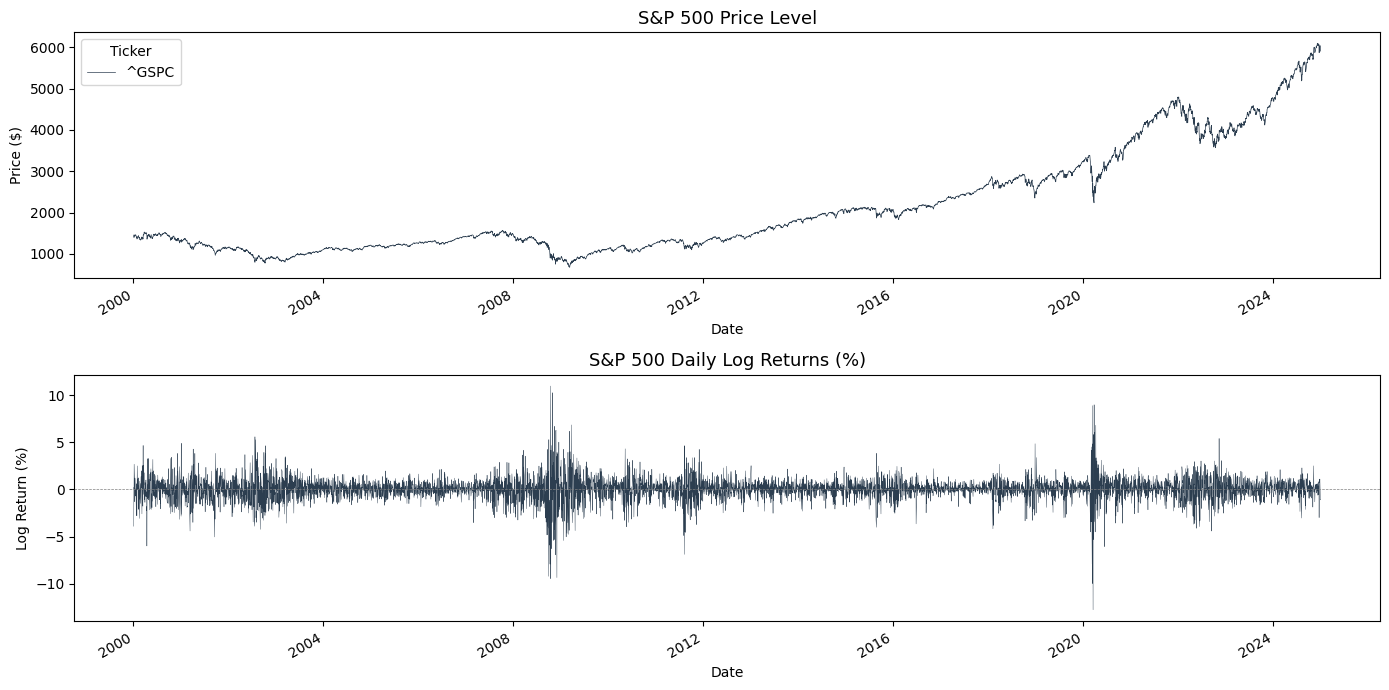

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [30]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [31]:
# -----------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# Fill in the blanks to specify the model correctly
# -----------------------------------------------------------
from arch import arch_model

garch = arch_model(returns, vol='Garch', p=1, q=1, mean='AR', lags=1)
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())
# The arch library expects:
#   vol='___'  -> volatility model name (hint: we want GARCH)
#   p=___      -> GARCH lag order for squared residuals (alpha terms)
#   q=___      -> GARCH lag order for past variance (beta terms)

garch_spec = arch_model(
    returns,
    mean='Constant',       # constant mean model
    vol='Garch',             # FILL IN: volatility model type
    p=1,                 # FILL IN: order of the ARCH term
    q=1,                 # FILL IN: order of the GARCH term
    dist='normal'          # innovation distribution
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

# VERIFICATION
# alpha[1] + beta[1] should be < 1 (variance stationarity)
params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)
print(f'\nalpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {alpha1 + beta1:.4f} (must be < 1 for stationarity)')
print(f'Half-life of volatility shocks: {np.log(2) / (-np.log(alpha1 + beta1)):.1f} days')

                           AR - GARCH Model Results                           
Dep. Variable:             log_return   R-squared:                       0.007
Mean Model:                        AR   Adj. R-squared:                  0.006
Vol Model:                      GARCH   Log-Likelihood:               -8644.25
Distribution:                  Normal   AIC:                           17298.5
Method:            Maximum Likelihood   BIC:                           17332.2
                                        No. Observations:                 6286
Date:                Fri, Apr 17 2026   Df Residuals:                     6284
Time:                        00:02:09   Df Model:                            2
                                    Mean Model                                   
                    coef    std err          t      P>|t|        95.0% Conf. Int.
---------------------------------------------------------------------------------
Const             0.0654  1.051e-02      6.

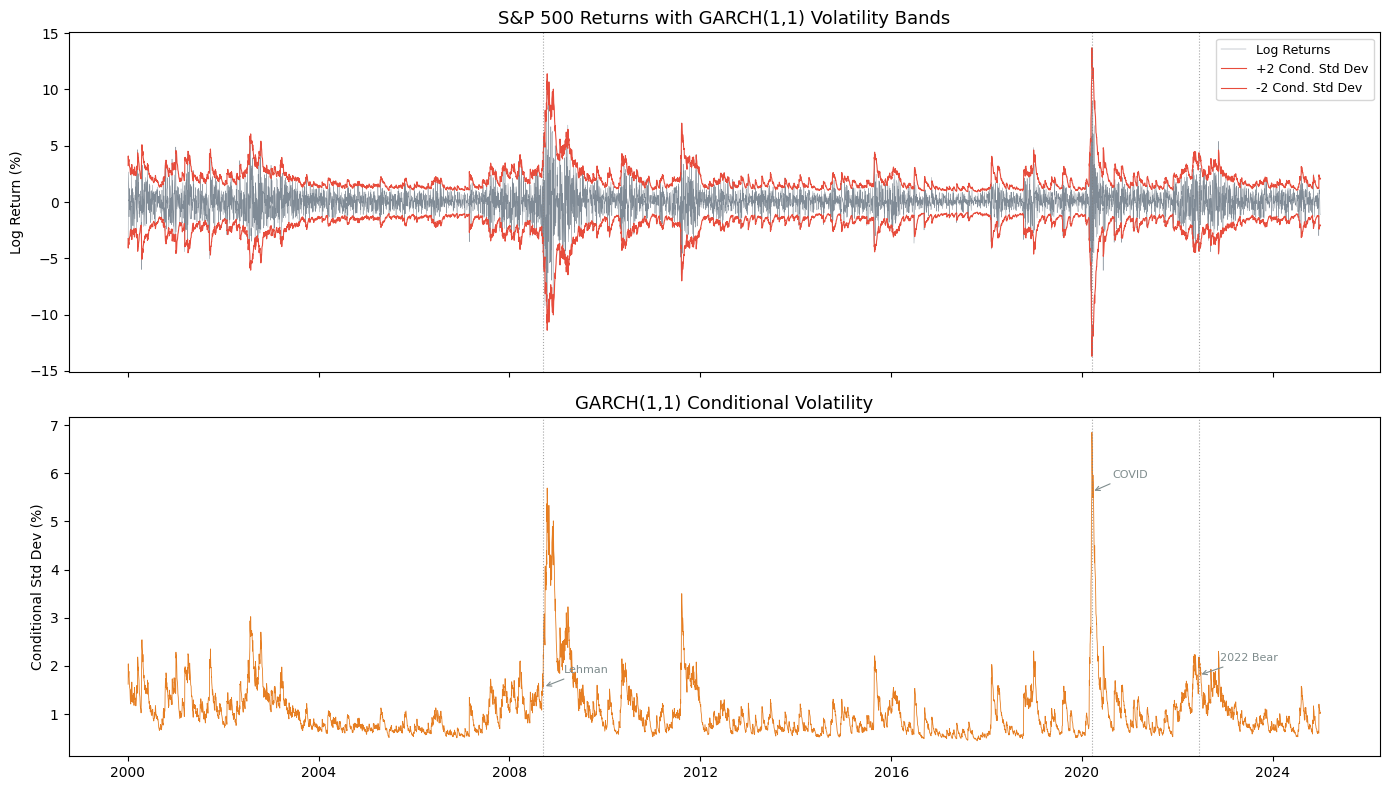

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1628%
Max conditional volatility: 6.8504% on 2020-03-17


In [32]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [33]:
# src/forecast_evaluation.py
"""Forecast evaluation utilities for time series models."""

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX


def compute_mase(actual: np.ndarray, predicted: np.ndarray,
                 train: np.ndarray, m: int = 12) -> float:
    """Compute Mean Absolute Scaled Error.

    Args:
        actual: Array of actual out-of-sample values.
        predicted: Array of predicted values (same length as actual).
        train: Array of in-sample training values.
        m: Seasonal period for naive benchmark (12 for monthly).

    Returns:
        MASE value. < 1 means model beats seasonal naive.
    """
    forecast_mae = np.abs(actual - predicted).mean()
    naive_mae = np.abs(train[m:] - train[:-m]).mean()
    return forecast_mae / naive_mae


def backtest_expanding_window(series: pd.Series, model_fn,
                               n_splits: int = 5) -> list:
    """Expanding-window backtest for time series models.

    Args:
        series: Full time series (pandas Series with DatetimeIndex).
        model_fn: Callable that takes (train_series) and returns
                  predicted values for h steps ahead.
        n_splits: Number of expanding windows.

    Returns:
        List of MASE scores, one per split.
    """
    from sklearn.model_selection import TimeSeriesSplit

    tscv = TimeSeriesSplit(n_splits=n_splits)
    mase_scores = []

    for train_idx, test_idx in tscv.split(series):
        train = series.iloc[train_idx]
        test = series.iloc[test_idx]
        h = len(test)

        predicted = model_fn(train, h)
        mase = compute_mase(test.values, predicted, train.values, m=12)
        mase_scores.append(mase)

    return mase_scores


if __name__ == "__main__":
    # Quick test
    train = np.sin(np.linspace(0, 8*np.pi, 120))  # 10 years of synthetic monthly data
    actual = np.sin(np.linspace(8*np.pi, 9*np.pi, 12))
    predicted = actual + np.random.normal(0, 0.1, 12)

    mase = compute_mase(actual, predicted, train, m=12)
    print(f"Test MASE: {mase:.3f}")

Test MASE: 0.053
